<a href="https://colab.research.google.com/github/hannahandkush/Coursework/blob/main/notebooks/Assignment3DataLoadingPyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Pipeline for deep learning with PyTorch**

## Major steps from data to deployment

| Step                | Key Actions                                                                | Main PyTorch Classes/Methods                  |
|---------------------|----------------------------------------------------------------------------|-----------------------------------------------|
| Data Preparation    | Load, transform, batch, and split data                                     | `torch.utils.data.Dataset`, `DataLoader`, `torchvision.transforms`  |
| Model Development   | Define architecture, choose loss/optimizer, set hyperparameters            | `torch.nn.Module`, `torch.nn.Parameter`, `torch.nn.functional`, `torch.optim` |
| Model Training      | Forward pass, loss computation, backward pass, parameter update, epochs    | `forward()`, `loss.backward()`, `optimizer.step()`, `optimizer.zero_grad()` , `model.train()` |
| Validation          | Evaluate on validation set, compute metrics, tune hyperparameters          | `model.eval()`, `torch.no_grad()`, metric functions (e.g., `torchmetrics`) |
| Testing/Deployment  | Final evaluation on test set, save and deploy model                        | `torch.save()`, `torch.load()`, `model.eval()`, `torch.jit` |

## Typical training loop.

Recall that the whole set of examples is visited during one epoch. Moreover, the *dataloader* groups examples in batches, and defines some other functionalities like shuffling the examples each time the iterator is created with `for inputs, targets in dataloader` in the example below.

For standard neural network training in PyTorch, inputs and targets should be tensors. This can be dealt with in the *data preparation* step, using `transforms` when creating the custom `Dataset` class for the problem at hand (see https://github.com/isa-ulisboa/greends-pml/blob/main/notebooks/T6_pytorch_dataset_dataloader.ipynb).

As discussed in https://github.com/isa-ulisboa/greends-pml/blob/main/docs/T1_basic_concepts.md for a simple linear regression problem, PyTorch uses **backpropagation** as the strategy to updates the model weights for loss minimization. The exact same idea can be generalized to multilayer neural networks and deep-learning.

The typical training loop in PyTorch is described in the code below.
1. The forward pass is done with `model(inputs)` that applies the model to the input and computes the output. This is a probability distribution over the possible labels.
2. The backward pass is done with `optimizer.step()` using the gradient computed with `loss.backward()`. The loss, as always, depends on the actual output `target` and the predicted output `outputs`. The line of code `optimizer.zero_grad()` prevents the gradients to be summed up along the process. For  backpropagation to work, the model must be in training mode, which it is set by default or by setting `model.train()`.

  ```
  for epoch in range(num_epochs):
      for inputs, targets in dataloader:
          optimizer.zero_grad()
          outputs = model(inputs)
          loss = criterion(outputs, targets)
          loss.backward()
          optimizer.step()
  ```

## Example for data preparation and model training: the MNIST data set

### Step 1: Data preparation

In [1]:
!pip install torchvision

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import time

In [28]:
# Define a transformation to flatten the 8x8 images
transform = transforms.Compose([
    transforms.Resize((8, 8)),  # Resize the PIL Image to 8x8 first (MNIST images are originally 28x28)
    transforms.ToTensor(),             # Then convert to tensor
    transforms.Lambda(lambda x: x.view(-1))  # Finally, flatten the tensor
])

# Load the MNIST dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

**Question**. Dataloaders `train_loader` and `test_loader` are iterators which allow to access examples and labels.
- What is the type of objects yielded by the train and test dataloaders?
- What is the *shape* of `images` returned by `for images, labels in train_loader`? How do you interpret that shape?
- Why dataloaders for train and test differ with respect to the option `shuffle`?

In [29]:
# Promt: Print a single sample of transforms.Lambda(lambda x: x.view(-1))
# Get a single sample from the train_dataset
sample_image, sample_label = train_dataset[0]

# The transform (including transforms.Lambda(lambda x: x.view(-1))) is already applied when accessing dataset items

# Print the shape of the transformed sample
print(f"Shape of a single transformed sample: {sample_image.shape}")
print(f"Content of a single transformed sample (first 10 elements): {sample_image[:10]}")
print(f"Corresponding label: {sample_label}")

Shape of a single transformed sample: torch.Size([64])
Content of a single transformed sample (first 10 elements): tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0039])
Corresponding label: 5


In [30]:
# Promt: What is the shape of images returned by for images, labels in train_loader? - Get one batch from the train_loader to inspect its shape
for images, labels in train_loader:
    print(f"Shape of 'images' from train_loader: {images.shape}")
    print(f"Shape of 'labels' from train_loader: {labels.shape}")
    break # We only need one batch for inspection

print("\nInterpretation:")
print("The shape `torch.Size([64, 64])` means that each batch contains 64 images (the batch size), and each image is a flattened tensor of 64 pixels (since the original 8x8 image was flattened).")
print("The shape `torch.Size([64])` for labels means there are 64 labels in the batch, one for each image.")

Shape of 'images' from train_loader: torch.Size([64, 64])
Shape of 'labels' from train_loader: torch.Size([64])

Interpretation:
The shape `torch.Size([64, 64])` means that each batch contains 64 images (the batch size), and each image is a flattened tensor of 64 pixels (since the original 8x8 image was flattened).
The shape `torch.Size([64])` for labels means there are 64 labels in the batch, one for each image.


#### **Answers**

*   The objects yielded by the `train_loader` and and `test_loader` are tensors. The initial image is resized from 28 x 28 pixels to 8 x 8 and then transformed into a 1D vector. They do not include any weights or biases because these are learned during the training process and this is just the input stage.
*   `images, labels in train_loader` returned the shape is [64,64] meaning there are 64 images in each batch, and each image is flattened into a 64 pixel tensor (8 by 8).
* `shuffle` is only used `(shuffle=True)` during training because at the begining of each epoc, sample order must be randomised to prevent overfitting and ensure each batch represents the diversity within the dataset. Whereas for `test_loader`the order of evaluation doesn't influence the accuracy when testing for the model's performance. Maintaining `(shuffle=False)` maintains reproducability.


#### Visualize some examples and labels

Since the `transform` that was applied above returns flattened tensors, one needs to unflatten them to be able to create an image that can be plotted.

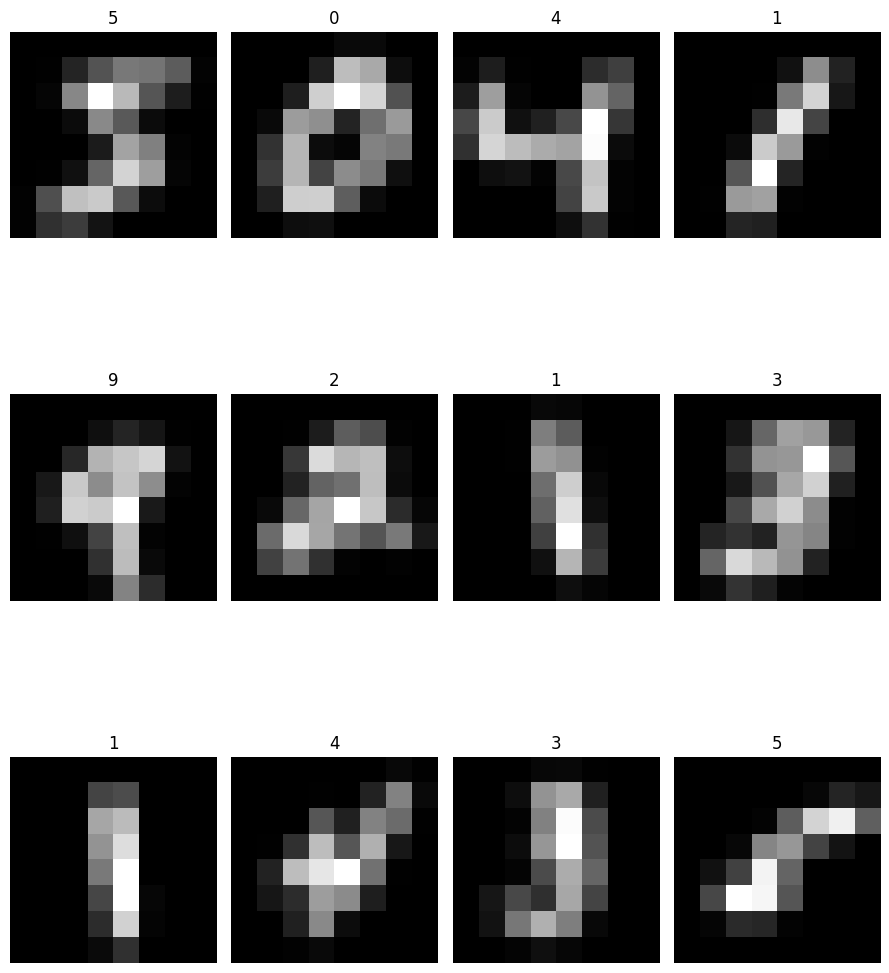

In [31]:
# Assuming each image is a 1D tensor of length 64 (8*8)
images, labels = zip(*[train_dataset[i] for i in range(12)]) # Visualize only the first 12 examples

fig, axes = plt.subplots(3, 4, figsize=(9, 12))
for i, ax in enumerate(axes.flat):
    img = images[i].reshape(8, 8)  # Unflatten to 2D  <-------- change 2 from reshape(8,8) to reshape(28,28)
    ax.imshow(img, cmap='gray')
    ax.set_title(str(labels[i]), fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

### Step 2: model development

In [37]:
# Model Development: the model is a multilayer perceptron with one hidden layer
class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        #self.fc2 = nn.Linear(hidden_size, hidden_size) # Second hidden layer
        #self.relu2 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

# original: Since we are using 8x8 MNIST and flatenning the input, the input size is 8 * 8 = 64
# edit: Input size is 28 * 28 = 784
input_size = 8 * 8
hidden_size = 128
num_classes = 10 # 0-9 digits

model = SimpleNN(input_size, hidden_size, num_classes)

**Question**:
- The model architecture depends on the input data shape. The input images of MNIST are originally of size $28 \times 28$ but they have been resized to $8 \times 8$ pixels. Which changes do you need to do if you want to use the original $28 \times 28$ size? Indicate two changes you need to do in this notebook.

```
Changes:
1. commented out, transforms.Resize((8, 8)), # (MNIST images are originally 28x28)
2. img = images[i].reshape(28, 28) # not reshape(8,8)
3. (input_size = 28 * 28 # not = 8 * 8)
```

- Which change you need to do in the `SimpleNN` class if you want your model to have two hidden layers, both with size 128?

```
#before: self.relu = nn.ReLU()
self.fc2 = nn.Linear(hidden_size, hidden_size)
self.relu2 = nn.ReLU()
# after: self.fc2 = nn.Linear(hidden_size, num_classes)
```
- What is a `ReLU` activation function called by `nn.ReLU`?


```
# ReLU (Rectified Linear Unit) returns the input if positive and if zero or negative, returns 0.
```

- Why are non linear activation functions like `ReLU` necessary for deep learning?

```
This prevents the vanishing gradient problem during backpropogation in recurrent neural networks.
Terms related to network weights are repeatedly multiplied so the error signal weakens.
ReLu is a better acitvation function, it doesn't squash the gradient into a small value.

In [33]:
# Loss and optimizer: necessary for training
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

#### Some details about cross entropy, softmax, one hot encoding and distributions

Since the problem is a *classification problem*, the criterion to compare model predictions with actual labels (what was denoted be $y$ and $\hat{y}$ for regression) is typically `criterion = nn.CrossEntropyLoss()`. This function has two arguments:
1. the output of the model (a list of scores returned by the model for each possible class, where the largest score corresponds to the most likely class) and
2. the target, which is the actual label of example. For instance if there are 10 classes $0, 1, \dots, 9$, the output would be a list like $[0.3,1.2,2.5,0.2,...]$ with 10 values, and the target could be 2 for instance.

The `nn.CrossEntropyLoss()` function will internally process the scores an the target the following way.

1. **Scores**. The unormalized model outputs $f_1, \dots, f_k$ are called *scores*, *logits* or *raw* outputs. Each score $z_i=f_i({\rm \bf x};{\rm \bf w_i})$ is converted into a [0,1] value by the *softmax* function:
$$p_i=\frac{\exp(z_i)}{\sum_{j=1}^k \exp(z_j)} ~~ {\rm which~implies~that} ~~ 0<p_i \le 1.$$
After that transformation, the classification model's probabilistic output is a vector of values $(p_1,\dots,p_k)$, with $p_i \ge 0$ and $\sum p_i=1$ as required for  probability distributions. The predicted label is the one with highest $p$.

<img src="https://drive.google.com/uc?export=view&id=1iD519g8QbBmOGp9SiOQsIneJnWg53SMQ" width="600" >


2. **Target**. A target value of, say, 2 is one-hot-encoded into the list $[0,0,1,0,...,0]$ of length 10.

The **cross-entropy loss** measures the dissimilarity between the probability distribution returned by *softmax* $(p_1,p_2,\dots)$ and the one hor encoded target distribution $(t_1,t_2,\dots)$ for each example. Its value range from 0 (optimal value associated to minimum uncertainty) and 1 (maximum value associated to maximum uncertainty, i.e. all probabilities are equal):

$$L_{single~example}=-\left( t_1 \, \log(p_1) + t_2 \, \log(p_2) + \dots \right) \in [0,1].$$

In the expression above, we suppose that the probabilities $p_i$ are non zero which is guaranteed by the *softmax* function.

For a batch of $n$ examples, the cross-entropy loss is given by the average of the $n$ individual loss values, where $L_i$ is the cross entropy for the $i$th example:

$$L_{batch}=\frac{1}{n} \left( L_1+L_2+ \dots,L_n\right).$$


### Step 3: Model training

In [40]:
# number of epochs
num_epochs = 3

#### Typical training loop

In [41]:
for epoch in range(num_epochs):
    print(f'epoch: {epoch+1}; time: {round(time.time())}')
    model.train()
    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


epoch: 1; time: 1779233800
epoch: 2; time: 1779233809
epoch: 3; time: 1779233819


**Question/Prompt**. Does processing time decreases if you add the option `num_workers=2` when defining the dataloader? Compute training time with and without that option and show the results for comparison.




In [42]:
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

def train_model(model, train_loader, test_loader, num_epochs, criterion, optimizer, device):
    start_time = time.time()
    for epoch in range(num_epochs):
        model.train()
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # Optional: Add validation here if needed for more accurate time comparison
        # For this comparison, we'll focus on the training loop itself.

    end_time = time.time()
    return end_time - start_time

# Re-define model and optimizer to ensure fresh state for each run
model_no_workers = SimpleNN(input_size, hidden_size, num_classes).to(device)
optimizer_no_workers = optim.Adam(model_no_workers.parameters(), lr=0.001)

print("Training without num_workers (default):")
time_no_workers = train_model(model_no_workers, train_loader, test_loader, num_epochs, criterion, optimizer_no_workers, device)
print(f"Training time without num_workers: {time_no_workers:.2f} seconds")

Using device: cuda
Training without num_workers (default):
Training time without num_workers: 29.87 seconds


In [43]:
# Create DataLoaders with num_workers=2
train_dataset_workers = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset_workers = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Ensure num_workers > 0 for this test if your environment supports it (e.g., not on Google Colab free tier with very limited CPU cores)
# For Colab, sometimes num_workers > 0 can be slower due to overhead if there aren't enough CPU cores.
num_workers_to_use = 2 # You can adjust this value

train_loader_workers = DataLoader(train_dataset_workers, batch_size=batch_size, shuffle=True, num_workers=num_workers_to_use)
test_loader_workers = DataLoader(test_dataset_workers, batch_size=batch_size, shuffle=False, num_workers=num_workers_to_use)

# Re-define model and optimizer for the second run
model_with_workers = SimpleNN(input_size, hidden_size, num_classes).to(device)
optimizer_with_workers = optim.Adam(model_with_workers.parameters(), lr=0.001)

print(f"\nTraining with num_workers={num_workers_to_use}:")
time_with_workers = train_model(model_with_workers, train_loader_workers, test_loader_workers, num_epochs, criterion, optimizer_with_workers, device)
print(f"Training time with num_workers={num_workers_to_use}: {time_with_workers:.2f} seconds")

print("\n--- Comparison ---")
print(f"Without num_workers: {time_no_workers:.2f} seconds")
print(f"With num_workers={num_workers_to_use}: {time_with_workers:.2f} seconds")

if time_with_workers < time_no_workers:
    print(f"Using num_workers={num_workers_to_use} was faster by {(time_no_workers - time_with_workers):.2f} seconds.")
elif time_with_workers > time_no_workers:
    print(f"Using num_workers={num_workers_to_use} was slower by {(time_with_workers - time_no_workers):.2f} seconds. This can happen in environments with limited CPU cores due to overhead.")
else:
    print("Both runs took approximately the same amount of time.")


Training with num_workers=2:
Training time with num_workers=2: 30.05 seconds

--- Comparison ---
Without num_workers: 29.87 seconds
With num_workers=2: 30.05 seconds
Using num_workers=2 was slower by 0.17 seconds. This can happen in environments with limited CPU cores due to overhead.


##### **Answer**

Adding a parallel data loading worker using `num_workers=2` decreased the training speed by 1.1 seconds to 30.05 seconds (default = 29.87 seconds). This means that the cost of initialising subprocesses was greater than the time saved by parallel loading. This is partly due to CPU limitations on Colab, only 2vCPU, meaning the OS has to constantly context switch pausing one process, saving its state, resuming another.

```
vCPU 1              vCPU 2
  |                   |
  |                   |
Main process       Worker 1    ← but there's also Worker 2...
(training loop)    (loading)     which requires switching
```
The switching costs time and none of the three processes gets to run at full speed. Whereas with `num_workers=0`, there's only the main process without context switching, IPC, or queue management costs. If there were more CPUs available this would differ.

Using num_workers=2 was faster by 1.17 seconds for 28 by 28 because each image is 12× larger (784 vs 64 pixels), so the data loading step takes longer to decode and transform. That makes parallel loading worth the overhead, and num_workers=2 actually helps.

#### Change device: run training on GPU

Training involves many large matrix computations. In general, this is done faster if it is parellelized over multiple cores. One can determine which device, either `cuda` (for GPU) or `cpu`, is used for training. Both model and data must be moved to the right device.

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model.to(device) #<<<<<<<<<< move model to device

# Re-initialize the optimizer after moving the model to the device
optimizer = optim.Adam(model.parameters(), lr=0.001)

#move data to GPU
for epoch in range(num_epochs):
    print(f'epoch: {epoch+1}; time: {round(time.time())}')
    model.train()
    for images, labels in train_loader:
        images = images.to(device)  #<<<<<<<<<< move data to device
        labels = labels.to(device)  #<<<<<<<<<< move data to device
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

Using device: cuda
epoch: 1; time: 1779228468
epoch: 2; time: 1779228478
epoch: 3; time: 1779228488


### Step 4: Validation

Validation is important for several goals, including:
- to estimate the accuracy of the model for the task at hand;
- to determine the optimal number of iterations (epochs);
- to be able to tune the model choosing the best hyperparameters.

Below, we will concentrate on the first two of those issues, and we will compare the estimated overall accuracy over the train and the test sets. In order to do this need to keep track of the intermediate results for each epoch and each batch of examples.

In [15]:
# Model Training
num_epochs = 5

# Computes the accuracy for a batch: outputs are probability-like values
def compute_accuracy(outputs, labels):
    _, predicted = torch.max(outputs.data, 1)
    correct = (predicted == labels).sum().item()
    total = len(labels)
    return correct / total

# History object to keep track of accuracy along epochs
history = {'epoch': [], 'train_accuracy': [], 'val_accuracy': []}

for epoch in range(num_epochs):
    print(f'epoch: {epoch+1}; time: {round(time.time())}')
    model.train()
    batch_accuracies=[]
    for images, labels in train_loader:
        images = images.to(device)  #<<<<<<<<<< move data to device
        labels = labels.to(device)  #<<<<<<<<<< move data to device
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # compute accuracy over the batch
        batch_accuracies.append(compute_accuracy(outputs, labels))
    history['epoch'].append(epoch)
    history['train_accuracy'].append(sum(batch_accuracies) / len(batch_accuracies))

    # Validation phase
    print(f'epoch: {epoch+1}; time: {round(time.time())}')
    model.eval()
    batch_accuracies=[]
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)  #<<<<<<<<<< move data to device
            labels = labels.to(device)  #<<<<<<<<<< move data to device
            outputs = model(images)
            # compute accuracy over the batch
            batch_accuracies.append(compute_accuracy(outputs, labels))
        history['val_accuracy'].append(sum(batch_accuracies) / len(batch_accuracies))

epoch: 1; time: 1779228498
epoch: 1; time: 1779228509
epoch: 2; time: 1779228511
epoch: 2; time: 1779228521
epoch: 3; time: 1779228522
epoch: 3; time: 1779228532
epoch: 4; time: 1779228534
epoch: 4; time: 1779228543
epoch: 5; time: 1779228545
epoch: 5; time: 1779228554


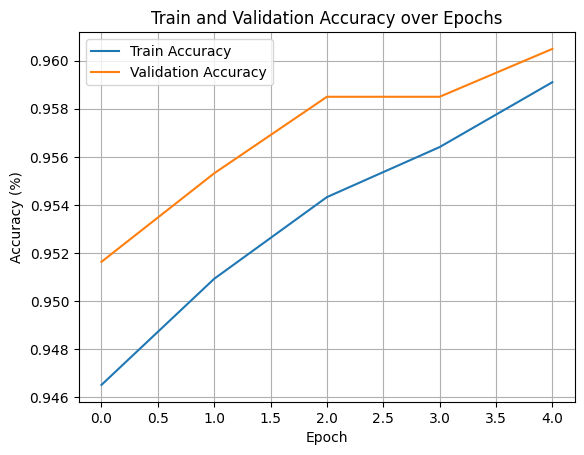

In [16]:
# accuracy plot
plt.plot(history['epoch'], history['train_accuracy'], label='Train Accuracy')
plt.plot(history['epoch'], history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Train and Validation Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()

**Question**:
- From the visualization of that plot, do you think that 5 epochs are enough, or should the model train longer than that?
- Can you find a reason for the validation curve to be consistently higher than the training curve, which in principle should not happen. Hint: look at how the history for train and validation are computed during model training, and correct the plot construction.



**Answers**

Both the visualation and validation plots are showing an increasing accuracy across epochs. The gap between them is also decreasing with time, suggesting more epochs could continue to increase accuracy.

The validation curve sitting consistently above the training curve occurs in the original graph because training accuracy is computed as a running average across batches within each epoch, early batches use weaker, updating weights, which drags the average down. Validation accuracy, by contrast, is evaluated once at the end of the epoch using the fully updated weights, so it reflects a stronger model. This systematic difference means validation accuracy will naturally appear slightly higher than training accuracy, even when the model is generalising well.

Below I experimented with different epoch numbers to determine an optimal stopping point, initially using the graph and when after 20 epochs that remainded unclear I used early stopping by tracking validation accuracy and stopping after it stops improving.

In [17]:
# Model Training
num_epochs = 10

# Computes the accuracy for a batch: outputs are probability-like values
def compute_accuracy(outputs, labels):
    _, predicted = torch.max(outputs.data, 1)
    correct = (predicted == labels).sum().item()
    total = len(labels)
    return correct / total

# History object to keep track of accuracy along epochs
history = {'epoch': [], 'train_accuracy': [], 'val_accuracy': []}

for epoch in range(num_epochs):
    print(f'epoch: {epoch+1}; time: {round(time.time())}')
    model.train()
    batch_accuracies=[]
    for images, labels in train_loader:
        images = images.to(device)  #<<<<<<<<<< move data to device
        labels = labels.to(device)  #<<<<<<<<<< move data to device
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # compute accuracy over the batch
        batch_accuracies.append(compute_accuracy(outputs, labels))
    history['epoch'].append(epoch)
    history['train_accuracy'].append(sum(batch_accuracies) / len(batch_accuracies))

    # Validation phase
    print(f'epoch: {epoch+1}; time: {round(time.time())}')
    model.eval()
    batch_accuracies=[]
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)  #<<<<<<<<<< move data to device
            labels = labels.to(device)  #<<<<<<<<<< move data to device
            outputs = model(images)
            # compute accuracy over the batch
            batch_accuracies.append(compute_accuracy(outputs, labels))
        history['val_accuracy'].append(sum(batch_accuracies) / len(batch_accuracies))

epoch: 1; time: 1779229857
epoch: 1; time: 1779229867
epoch: 2; time: 1779229868
epoch: 2; time: 1779229878
epoch: 3; time: 1779229880
epoch: 3; time: 1779229889
epoch: 4; time: 1779229891
epoch: 4; time: 1779229901
epoch: 5; time: 1779229902
epoch: 5; time: 1779229912
epoch: 6; time: 1779229913
epoch: 6; time: 1779229923
epoch: 7; time: 1779229925
epoch: 7; time: 1779229935
epoch: 8; time: 1779229937
epoch: 8; time: 1779229947
epoch: 9; time: 1779229948
epoch: 9; time: 1779229958
epoch: 10; time: 1779229960
epoch: 10; time: 1779229970


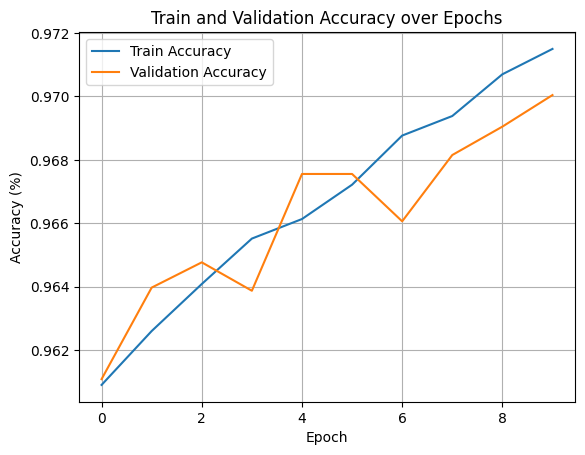

In [18]:
# accuracy plot
plt.plot(history['epoch'], history['train_accuracy'], label='Train Accuracy')
plt.plot(history['epoch'], history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Train and Validation Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
# Model Training
num_epochs = 20

# Computes the accuracy for a batch: outputs are probability-like values
def compute_accuracy(outputs, labels):
    _, predicted = torch.max(outputs.data, 1)
    correct = (predicted == labels).sum().item()
    total = len(labels)
    return correct / total

# History object to keep track of accuracy along epochs
history = {'epoch': [], 'train_accuracy': [], 'val_accuracy': []}

for epoch in range(num_epochs):
    print(f'epoch: {epoch+1}; time: {round(time.time())}')
    model.train()
    batch_accuracies=[]
    for images, labels in train_loader:
        images = images.to(device)  #<<<<<<<<<< move data to device
        labels = labels.to(device)  #<<<<<<<<<< move data to device
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # compute accuracy over the batch
        batch_accuracies.append(compute_accuracy(outputs, labels))
    history['epoch'].append(epoch)
    history['train_accuracy'].append(sum(batch_accuracies) / len(batch_accuracies))

    # Validation phase
    print(f'epoch: {epoch+1}; time: {round(time.time())}')
    model.eval()
    batch_accuracies=[]
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)  #<<<<<<<<<< move data to device
            labels = labels.to(device)  #<<<<<<<<<< move data to device
            outputs = model(images)
            # compute accuracy over the batch
            batch_accuracies.append(compute_accuracy(outputs, labels))
        history['val_accuracy'].append(sum(batch_accuracies) / len(batch_accuracies))

epoch: 1; time: 1779230408
epoch: 1; time: 1779230418
epoch: 2; time: 1779230420
epoch: 2; time: 1779230430
epoch: 3; time: 1779230431
epoch: 3; time: 1779230441
epoch: 4; time: 1779230443
epoch: 4; time: 1779230453
epoch: 5; time: 1779230454
epoch: 5; time: 1779230464
epoch: 6; time: 1779230466
epoch: 6; time: 1779230476
epoch: 7; time: 1779230477
epoch: 7; time: 1779230488
epoch: 8; time: 1779230489
epoch: 8; time: 1779230499
epoch: 9; time: 1779230501
epoch: 9; time: 1779230513
epoch: 10; time: 1779230514
epoch: 10; time: 1779230525
epoch: 11; time: 1779230526
epoch: 11; time: 1779230537
epoch: 12; time: 1779230539
epoch: 12; time: 1779230550
epoch: 13; time: 1779230552
epoch: 13; time: 1779230562
epoch: 14; time: 1779230564
epoch: 14; time: 1779230574
epoch: 15; time: 1779230575
epoch: 15; time: 1779230586
epoch: 16; time: 1779230588
epoch: 16; time: 1779230598
epoch: 17; time: 1779230600
epoch: 17; time: 1779230610
epoch: 18; time: 1779230612
epoch: 18; time: 1779230621
epoch: 19;

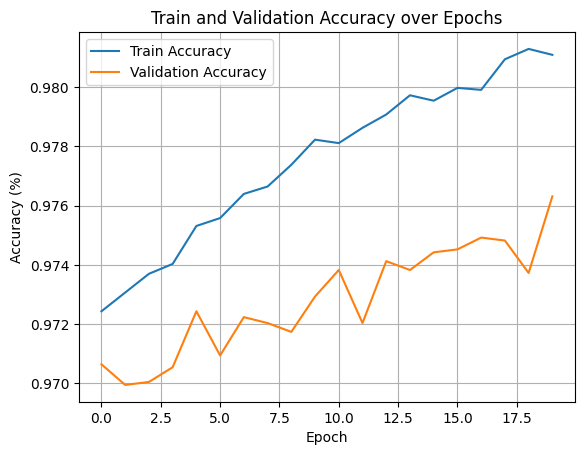

In [20]:
# accuracy plot
plt.plot(history['epoch'], history['train_accuracy'], label='Train Accuracy')
plt.plot(history['epoch'], history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Train and Validation Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()

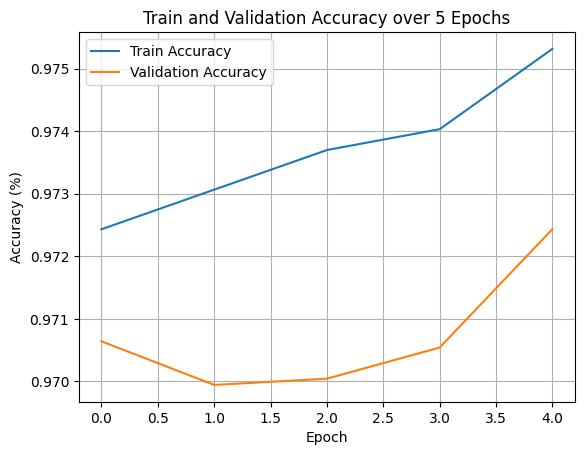

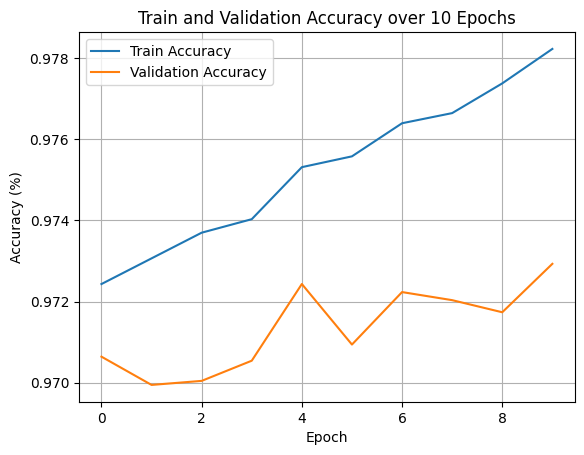

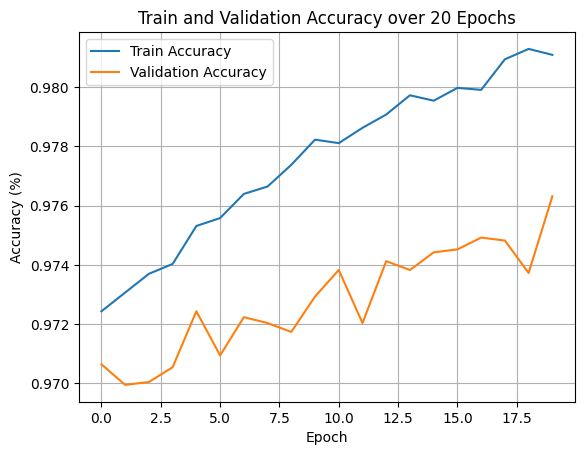

In [21]:
def plot_history(history, num_epochs):
    plt.plot(history['epoch'][:num_epochs], history['train_accuracy'][:num_epochs], label='Train Accuracy')
    plt.plot(history['epoch'][:num_epochs], history['val_accuracy'][:num_epochs], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title(f'Train and Validation Accuracy over {num_epochs} Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history(history, 5)   # same data, first 5 epochs
plot_history(history, 10)  # same data, first 10 epochs
plot_history(history, 20)  # same data, all 20 epochs

Epoch 1: train=0.8139, val=0.8992
Epoch 2: train=0.9022, val=0.9135
Epoch 3: train=0.9163, val=0.9248
Epoch 4: train=0.9275, val=0.9326
Epoch 5: train=0.9340, val=0.9415
Epoch 6: train=0.9400, val=0.9459
Epoch 7: train=0.9451, val=0.9496
Epoch 8: train=0.9493, val=0.9530
Epoch 9: train=0.9528, val=0.9566
Epoch 10: train=0.9548, val=0.9593
Epoch 11: train=0.9578, val=0.9575
  No improvement for 1 epoch(s)
Epoch 12: train=0.9602, val=0.9627
Epoch 13: train=0.9614, val=0.9623
  No improvement for 1 epoch(s)
Epoch 14: train=0.9625, val=0.9638
Epoch 15: train=0.9642, val=0.9647
Epoch 16: train=0.9658, val=0.9660
Epoch 17: train=0.9667, val=0.9662
Epoch 18: train=0.9674, val=0.9663
Epoch 19: train=0.9685, val=0.9674
Epoch 20: train=0.9695, val=0.9689
Epoch 21: train=0.9703, val=0.9702
Epoch 22: train=0.9707, val=0.9715
Epoch 23: train=0.9717, val=0.9712
  No improvement for 1 epoch(s)
Epoch 24: train=0.9731, val=0.9721
Epoch 25: train=0.9728, val=0.9712
  No improvement for 1 epoch(s)
Epoch 

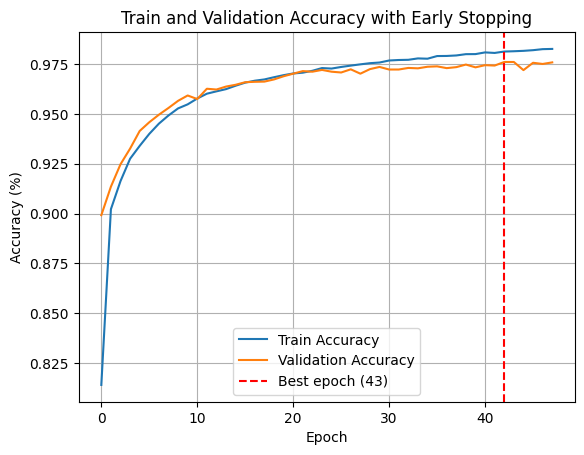

In [23]:
# Prompt: write some code for early stopping to tell me what is the optimal epoch number

torch.manual_seed(42)
model = SimpleNN(input_size, hidden_size, num_classes).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Early stopping parameters
patience = 5          # how many epochs to wait for improvement
best_val_accuracy = 0
epochs_without_improvement = 0
best_epoch = 0

history = {'epoch': [], 'train_accuracy': [], 'val_accuracy': []}

for epoch in range(100):  # set high, early stopping will cut it short
    model.train()
    batch_accuracies = []
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        batch_accuracies.append(compute_accuracy(outputs, labels))

    train_acc = sum(batch_accuracies) / len(batch_accuracies)

    # Validation phase
    model.eval()
    batch_accuracies = []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            batch_accuracies.append(compute_accuracy(outputs, labels))

    val_acc = sum(batch_accuracies) / len(batch_accuracies)

    history['epoch'].append(epoch)
    history['train_accuracy'].append(train_acc)
    history['val_accuracy'].append(val_acc)

    print(f"Epoch {epoch+1}: train={train_acc:.4f}, val={val_acc:.4f}")

    # Early stopping check
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        best_epoch = epoch
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        print(f"  No improvement for {epochs_without_improvement} epoch(s)")

    if epochs_without_improvement >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        print(f"Best epoch: {best_epoch+1} with val accuracy: {best_val_accuracy:.4f}")
        break

# Plot
plt.plot(history['epoch'], history['train_accuracy'], label='Train Accuracy')
plt.plot(history['epoch'], history['val_accuracy'], label='Validation Accuracy')
plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best epoch ({best_epoch+1})')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Train and Validation Accuracy with Early Stopping')
plt.legend()
plt.grid(True)
plt.show()